# A01 - Regresión polinomial


## Para los datos de los archivos "bateria_tableta.txt" y "Salarios_minimos.csv":



In [6]:
# Lectura de datos
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df_bateria = pd.read_csv("bateria_tableta.txt")
df_salarios = pd.read_csv("Salarios_minimos.csv", encoding='UTF-8')

print(df_bateria.columns)
print(df_salarios.columns)



Index(['carga', 'duracion'], dtype='object')
Index(['Periodo', 'Salario'], dtype='object')


In [7]:
# --- BATERIA ---
# Convertimos a forma columna (N, 1) para hstack
X_bat = df_bateria['carga'].values.reshape(-1, 1) 
y_bat = df_bateria['duracion'].values

# --- SALARIOS ---
# Normalizamos X para evitar overflow en grado 7, pero guardamos el original para graficar
X_sal_raw = df_salarios['Periodo'].values
X_sal_norm = (X_sal_raw - X_sal_raw.min()).reshape(-1, 1) 
y_sal = df_salarios['Salario'].values

# Lista de grados solicitados (Realiza regresiones polinomiales de orden 1, 3, 5 y 7.)
grados = [1, 3, 5, 7]

print("Datos preparados correctamente.")

Datos preparados correctamente.


- Realiza regresiones polinomiales de orden 1, 3, 5 y 7.

- Compara el R2 que te da cada modelo.



In [4]:
# Diccionario para guardar los modelos entrenados y usarlos después
resultados = {
    'bateria': {},
    'salarios': {}
}

print(f"{'DATASET':<10} | {'GRADO':<5} | {'R2 SCORE':<10}")
print("-" * 30)

# --- ENTRENAMIENTO BATERIA ---
for g in grados:
    # 1. Crear matriz manual (hstack)
    cols = [X_bat**(i) for i in range(1, g + 1)]
    X_matriz = np.hstack(cols)
    
    # 2. Ajustar modelo
    model = LinearRegression()
    model.fit(X_matriz, y_bat)
    
    # 3. Calcular R2
    r2 = model.score(X_matriz, y_bat)
    
    # 4. Guardar para luego
    resultados['bateria'][g] = model
    print(f"{'Bateria':<10} | {g:<5} | {r2:.4f}")

print("-" * 30)

# --- ENTRENAMIENTO SALARIOS ---
for g in grados:
    # 1. Crear matriz manual (con X normalizado)
    cols = [X_sal_norm**(i) for i in range(1, g + 1)]
    X_matriz = np.hstack(cols)
    
    # 2. Ajustar modelo
    model = LinearRegression()
    model.fit(X_matriz, y_sal)
    
    # 3. Calcular R2
    r2 = model.score(X_matriz, y_sal)
    
    # 4. Guardar para luego
    resultados['salarios'][g] = model
    print(f"{'Salarios':<10} | {g:<5} | {r2:.4f}")

DATASET    | GRADO | R2 SCORE  
------------------------------
Bateria    | 1     | 0.6872
Bateria    | 3     | 0.9781
Bateria    | 5     | 0.9954
Bateria    | 7     | 0.9981
------------------------------
Salarios   | 1     | 0.9845
Salarios   | 3     | 0.9857
Salarios   | 5     | 0.9962
Salarios   | 7     | 0.9987


- Crea una gráfica con una nube de dispersión (datos originales) y tus modelos.



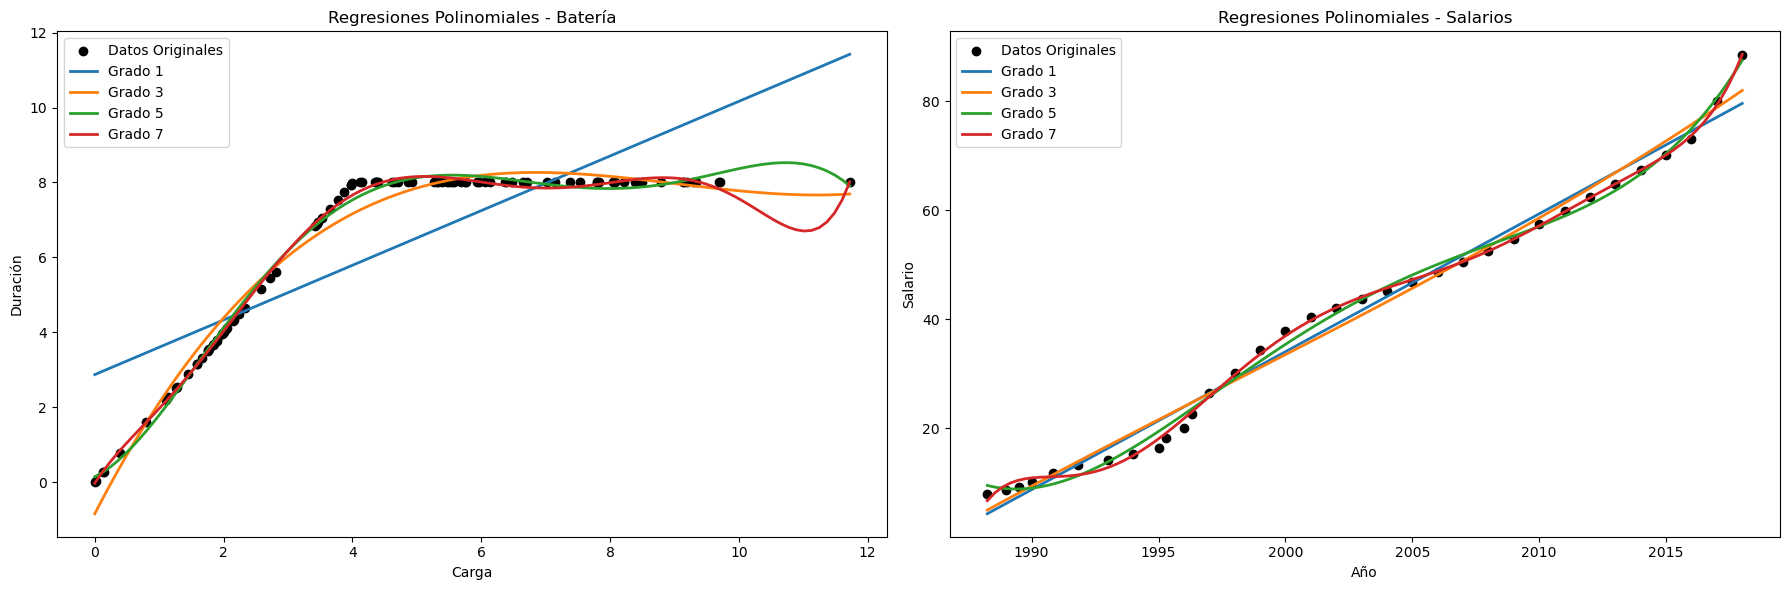

In [5]:
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE GRÁFICAS ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# === GRÁFICA 1: BATERÍA ===
ax = axes[0]
# 1. Nube de dispersión (Datos originales)
ax.scatter(X_bat, y_bat, color='black', label='Datos Originales')

# 2. Graficar cada modelo
linea_x = np.linspace(X_bat.min(), X_bat.max(), 100).reshape(-1, 1)

for g in grados:
    model = resultados['bateria'][g]
    
    # Crear matriz para la línea suave
    cols_linea = [linea_x**(i) for i in range(1, g + 1)]
    X_linea = np.hstack(cols_linea)
    
    y_pred = model.predict(X_linea)
    ax.plot(linea_x, y_pred, label=f'Grado {g}', linewidth=2)

ax.set_title("Regresiones Polinomiales - Batería")
ax.set_xlabel("Carga")
ax.set_ylabel("Duración")
ax.legend()


# === GRÁFICA 2: SALARIOS ===
ax = axes[1]
# 1. Nube de dispersión (Usamos X_sal_raw para ver los años reales)
ax.scatter(X_sal_raw, y_sal, color='black', label='Datos Originales')

# 2. Graficar cada modelo
# Usamos el rango normalizado para predecir, luego ajustamos para graficar
linea_x_norm = np.linspace(X_sal_norm.min(), X_sal_norm.max(), 100).reshape(-1, 1)

for g in grados:
    model = resultados['salarios'][g]
    
    # Crear matriz para la línea suave (usando X normalizado)
    cols_linea = [linea_x_norm**(i) for i in range(1, g + 1)]
    X_linea = np.hstack(cols_linea)
    
    y_pred = model.predict(X_linea)
    
    # Ajuste visual: sumar el año base para que coincida con el eje X real
    linea_x_real = linea_x_norm + X_sal_raw.min()
    
    ax.plot(linea_x_real, y_pred, label=f'Grado {g}', linewidth=2)

ax.set_title("Regresiones Polinomiales - Salarios")
ax.set_xlabel("Año")
ax.set_ylabel("Salario")
ax.legend()

plt.tight_layout()
plt.show()